# E337 - Grupo 1 - Trabajo Práctico 5
Integrantes: Constanza María Efkhanian - Julián Fabrizio Notario - María Florencia Pascale

# Bibliotecas

# Directorio y separación train/ test 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree

import warnings
warnings.filterwarnings('ignore')

import seaborn as sns
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import precision_score, f1_score, average_precision_score
from sklearn.metrics import precision_recall_curve

In [2]:
RUTA = "/Users/mariapascale/Documents/E337 | Big Data/E337_Grupo1/TP5"

df = pd.read_csv(f"{RUTA}/ocupados_tp4.csv")

# Separamos X e Y
X = df.drop('informal', axis=1)
y = df['informal']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f'Observaciones en train : {X_train.shape[0]}')
print(f'Observaciones en test  : {X_test.shape[0]}')
print(f'Tasa de informalidad (train): {y_train.mean().round(3)}')

Observaciones en train : 2475
Observaciones en test  : 1062
Tasa de informalidad (train): 0.257


# A. Árboles

### Ejercicio 1 

In [3]:
# Calculamos el camino de poda sobre datos de entrenamiento
arbol_base = DecisionTreeClassifier(random_state=42)
path = arbol_base.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Excluimos el último valor
ccp_alphas = ccp_alphas[:-1]

n_alphas = 40
if len(ccp_alphas) > n_alphas:
    indices = np.linspace(0, len(ccp_alphas) - 1, n_alphas, dtype=int)
    ccp_alphas = ccp_alphas[indices]

print(f'Cantidad de valores de alpha a evaluar: {len(ccp_alphas)}')
print(np.round(ccp_alphas, 6))

Cantidad de valores de alpha a evaluar: 40
[0.       0.000256 0.000262 0.000305 0.000314 0.000337 0.000351 0.000356
 0.000373 0.00038  0.000388 0.0004   0.000441 0.000481 0.000486 0.000496
 0.000511 0.000539 0.000539 0.000548 0.000606 0.000629 0.000639 0.000646
 0.000673 0.000684 0.00071  0.000738 0.000771 0.000788 0.000842 0.000907
 0.001034 0.001225 0.001282 0.001728 0.001764 0.002778 0.004247 0.010406]


In [4]:
cv = KFold(n_splits=10, shuffle=True, random_state=42)

errores_cv   = []
std_errores  = []

for alpha in ccp_alphas:
    fold_acc = []
    arbol = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)

    for train_idx, valid_idx in cv.split(X_train):
        x_tr, x_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        arbol.fit(x_tr, y_tr)
        fold_acc.append(arbol.score(x_val, y_val))

    errores_cv.append(1 - np.mean(fold_acc))
    std_errores.append(np.std(fold_acc))

errores_cv  = np.array(errores_cv)
std_errores = np.array(std_errores)

# Tabla de resumen
resultados = pd.DataFrame({
    'ccp_alpha'        : np.round(ccp_alphas, 6),
    'Error CV (media)' : np.round(errores_cv, 4),
    'Std CV'           : np.round(std_errores, 4)
})
print(resultados.to_string(index=False))

 ccp_alpha  Error CV (media)  Std CV
  0.000000            0.1208  0.0241
  0.000256            0.1200  0.0233
  0.000262            0.1200  0.0233
  0.000305            0.1147  0.0227
  0.000314            0.1147  0.0227
  0.000337            0.1135  0.0221
  0.000351            0.1135  0.0221
  0.000356            0.1135  0.0221
  0.000373            0.1131  0.0222
  0.000380            0.1107  0.0207
  0.000388            0.1103  0.0209
  0.000400            0.1099  0.0211
  0.000441            0.1079  0.0191
  0.000481            0.1075  0.0179
  0.000486            0.1075  0.0179
  0.000496            0.1067  0.0181
  0.000511            0.1063  0.0178
  0.000539            0.1067  0.0178
  0.000539            0.1067  0.0178
  0.000548            0.1059  0.0175
  0.000606            0.1071  0.0163
  0.000629            0.1067  0.0164
  0.000639            0.1063  0.0157
  0.000646            0.1063  0.0157
  0.000673            0.1046  0.0133
  0.000684            0.1038  0.0131
 

Alpha óptimo : 0.001034
Error CV mín : 0.0949


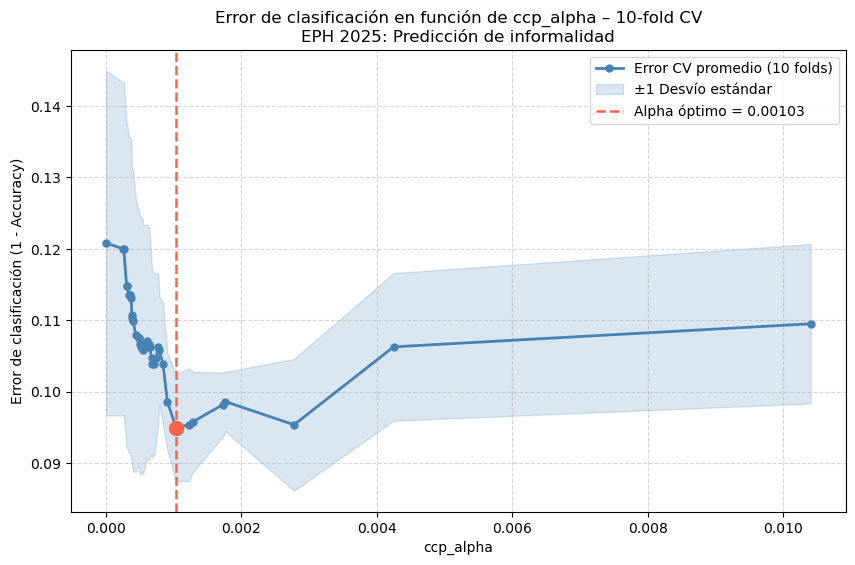

In [5]:
# Alpha óptimo: el que minimiza el error de CV
idx_optimo   = np.argmin(errores_cv)
alpha_optimo = ccp_alphas[idx_optimo]
error_optimo = errores_cv[idx_optimo]

print(f'Alpha óptimo : {alpha_optimo:.6f}')
print(f'Error CV mín : {error_optimo:.4f}')

# Gráfico de línea
plt.figure(figsize=(10, 6))
plt.plot(ccp_alphas, errores_cv,
         color='steelblue', marker='o', markersize=5,
         linewidth=2, label='Error CV promedio (10 folds)')
plt.fill_between(ccp_alphas,
                 errores_cv - std_errores,
                 errores_cv + std_errores,
                 alpha=0.2, color='steelblue', label='±1 Desvío estándar')
plt.axvline(x=alpha_optimo, color='tomato', linestyle='--', linewidth=1.8,
            label=f'Alpha óptimo = {alpha_optimo:.5f}')
plt.scatter([alpha_optimo], [error_optimo], color='tomato', s=100, zorder=5)
plt.xlabel('ccp_alpha')
plt.ylabel('Error de clasificación (1 - Accuracy)')
plt.title('Error de clasificación en función de ccp_alpha – 10-fold CV\nEPH 2025: Predicción de informalidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(
    "ej_A1.png",
    dpi=300,  # Alta resolución (ideal para impresión o pantallas)
    bbox_inches="tight",  # Evita que se corten las etiquetas o leyendas
    transparent=False,  # Cambia a True si quieres fondo transparente
)
plt.show()



In [6]:
# Entrenamos al árbol podado óptimo sobre X_train
arbol_podado = DecisionTreeClassifier(ccp_alpha=alpha_optimo, random_state=42)
arbol_podado.fit(X_train, y_train)

error_train = 1 - arbol_podado.score(X_train, y_train)
error_test  = 1 - arbol_podado.score(X_test, y_test)

print(f'Nodos terminales del árbol podado : {arbol_podado.tree_.n_leaves}')
print(f'Profundidad del árbol podado      : {arbol_podado.get_depth()}')
print(f'Error de clasificación en TRAIN   : {np.round(error_train, 4)}')
print(f'Error de clasificación en TEST    : {np.round(error_test, 4)}')

Nodos terminales del árbol podado : 32
Profundidad del árbol podado      : 10
Error de clasificación en TRAIN   : 0.0663
Error de clasificación en TEST    : 0.113


### Ejercicio 2

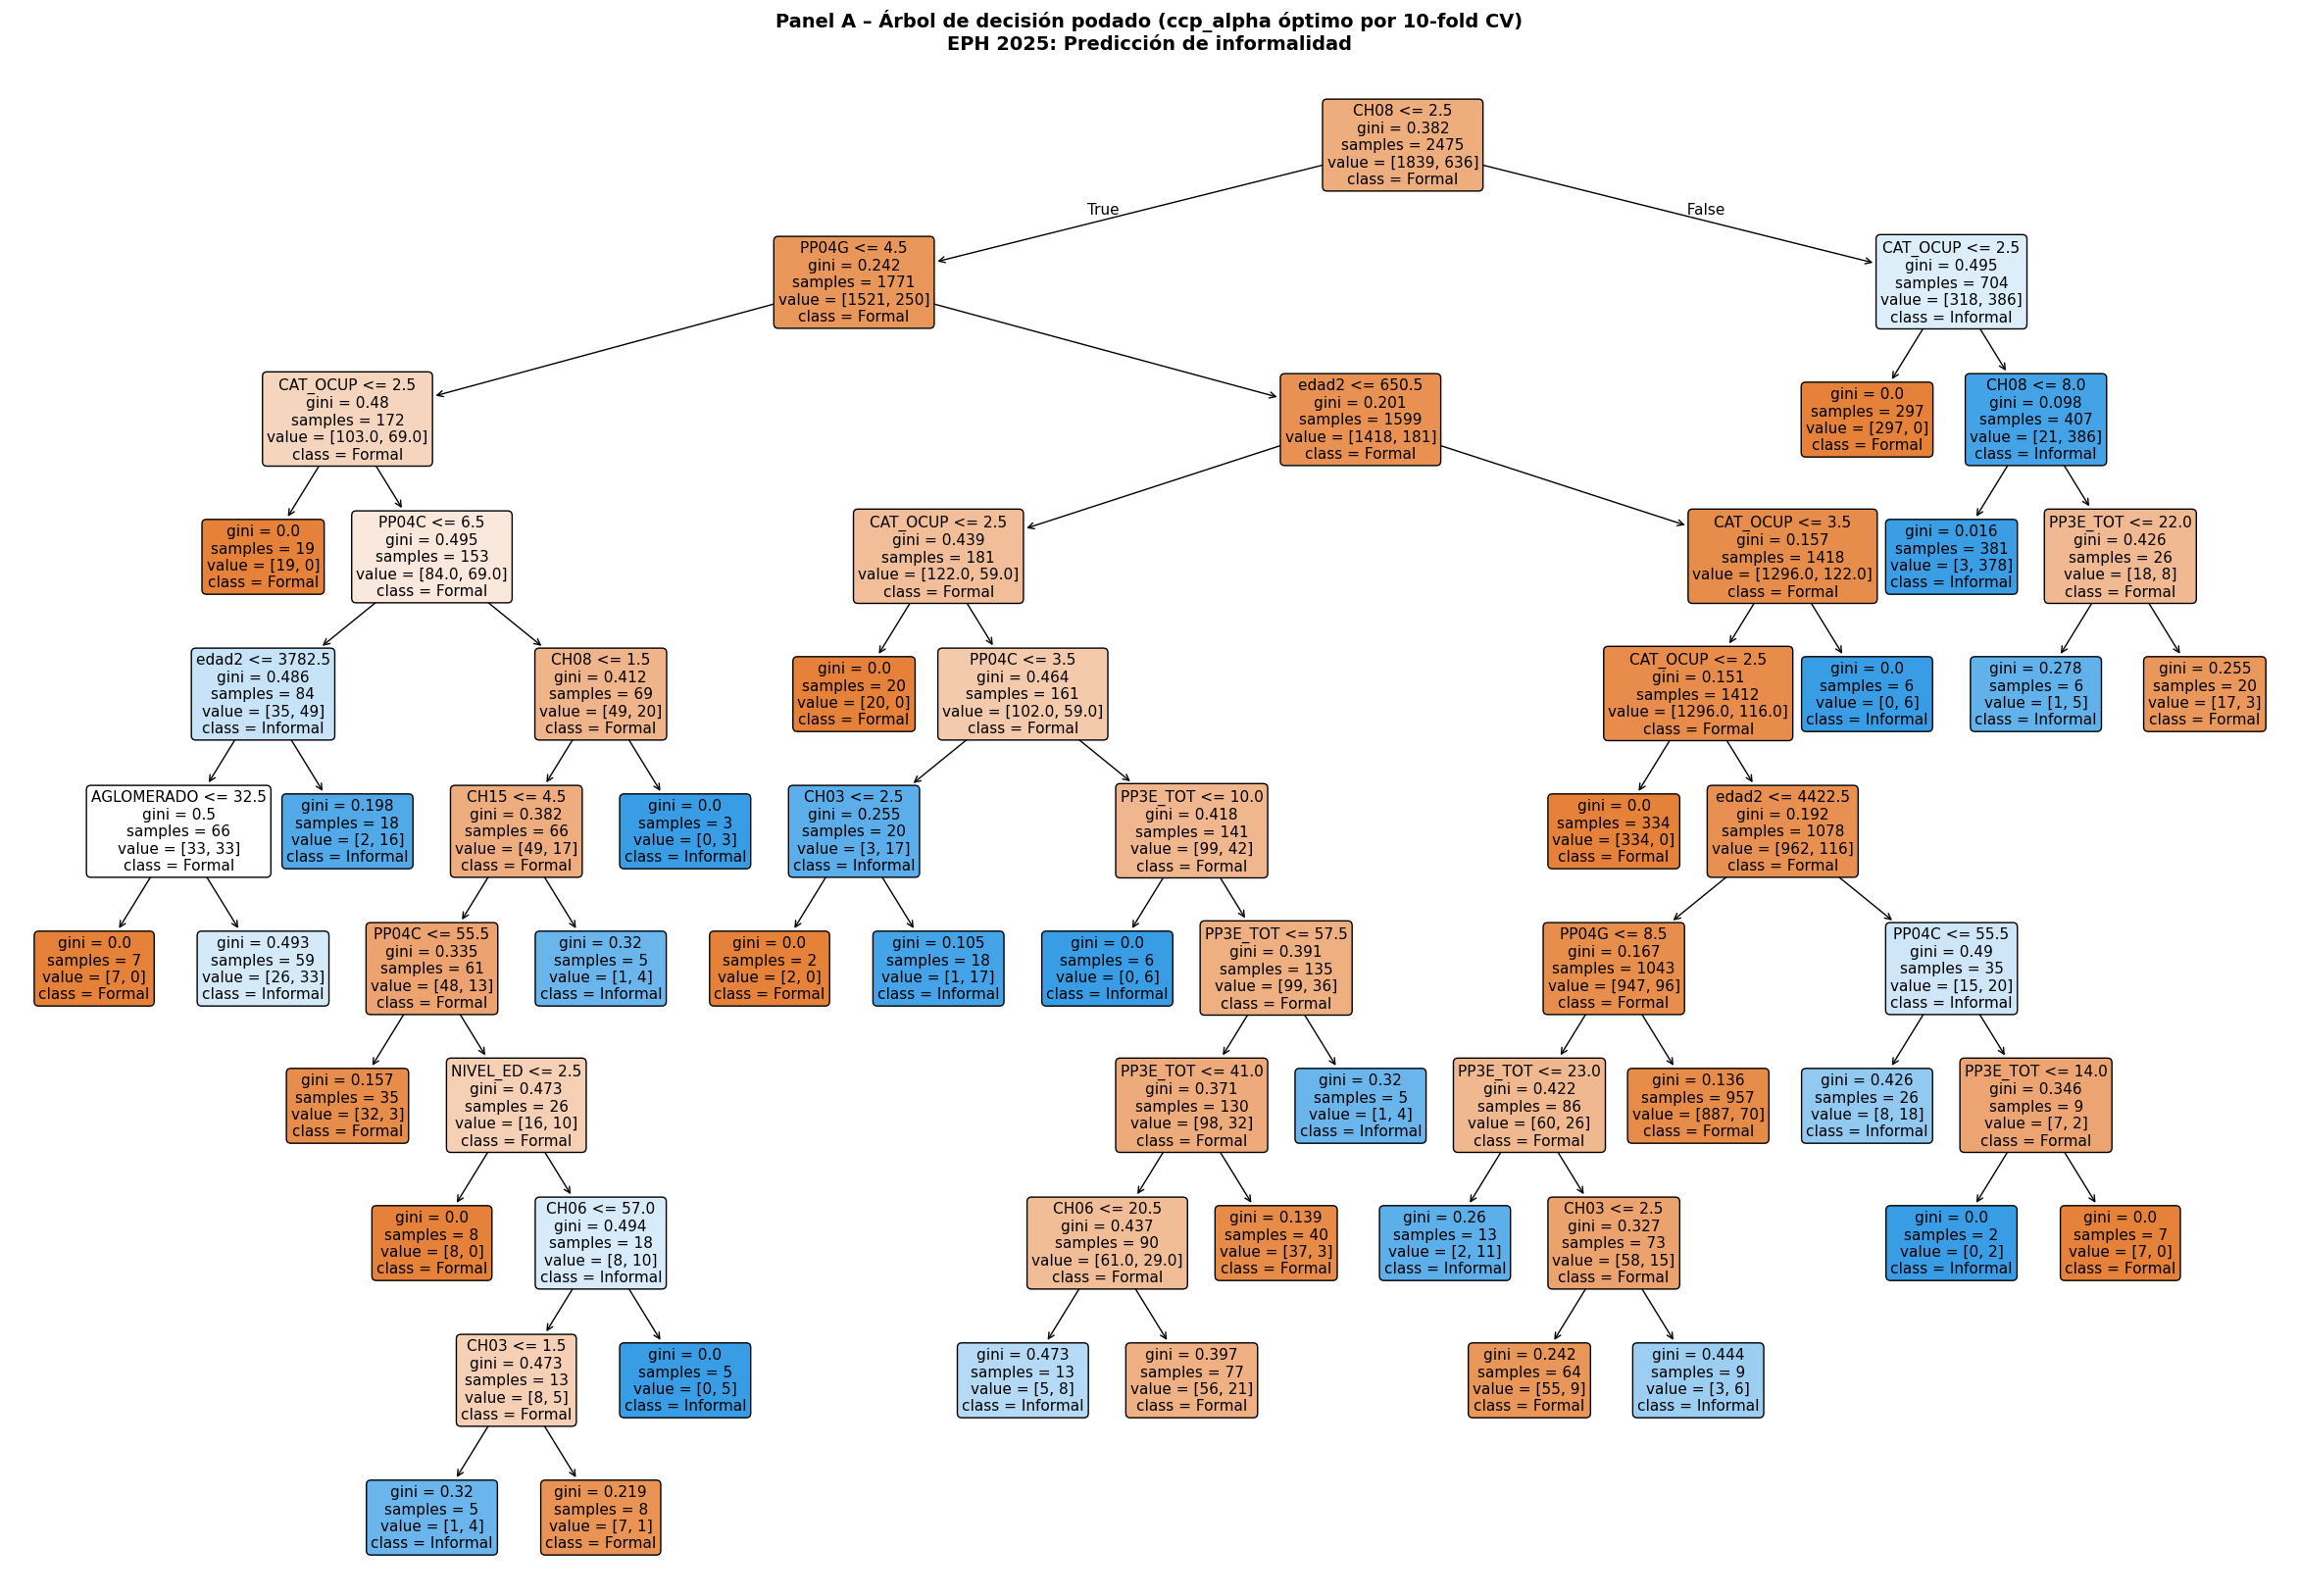

Nodos terminales : 32
Profundidad      : 10


In [7]:
fig = plt.figure(figsize=(30, 20))
plot_tree(arbol_podado,
          impurity=True,
          feature_names=list(X_train.columns),
          class_names=['Formal', 'Informal'],
          rounded=True,
          filled=True,
          fontsize=11)

plt.title('Panel A – Árbol de decisión podado (ccp_alpha óptimo por 10-fold CV)\nEPH 2025: Predicción de informalidad',
          fontsize=14, fontweight='bold', pad=20)
plt.savefig('TP5_A2_panel_A_arbol.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Nodos terminales : {arbol_podado.tree_.n_leaves}')
print(f'Profundidad      : {arbol_podado.get_depth()}')

# B. Comparación entre modelos

### Ejercicio 3

In [8]:
# Estandarizamos
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 1. Logit sin penalidad 
logit = LogisticRegression(C=1e10, solver='saga', max_iter=5000, random_state=42)
logit.fit(X_train_scaled, y_train)

# 2. KNN con K óptimo por 10-fold CV
cv_10       = KFold(n_splits=10, shuffle=True, random_state=42)
y_train_knn = y_train.reset_index(drop=True)   # índice 0-based para el loop
k_range     = range(1, 31)
knn_errores = []

for k in k_range:
    fold_acc = []
    for train_idx, valid_idx in cv_10.split(X_train_scaled):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_scaled[train_idx], y_train_knn.iloc[train_idx])
        fold_acc.append(knn.score(X_train_scaled[valid_idx], y_train_knn.iloc[valid_idx]))
    knn_errores.append(1 - np.mean(fold_acc))

k_optimo   = list(k_range)[np.argmin(knn_errores)]
knn_optimo = KNeighborsClassifier(n_neighbors=k_optimo)
knn_optimo.fit(X_train_scaled, y_train)
print(f'K óptimo (CV): {k_optimo}')

# 3. Logit LASSO 
logit_lasso = LogisticRegressionCV(
    penalty='l1', solver='liblinear', cv=10, max_iter=5000, random_state=42
)
logit_lasso.fit(X_train_scaled, y_train)
print(f'C óptimo LASSO : {np.round(logit_lasso.C_[0], 4)}')

# 4. Logit Ridge 
logit_ridge = LogisticRegressionCV(
    penalty='l2', solver='lbfgs', cv=10, max_iter=5000, random_state=42
)
logit_ridge.fit(X_train_scaled, y_train)
print(f'C óptimo Ridge : {np.round(logit_ridge.C_[0], 4)}')

# 5. CART: ya fue estimado en A.1 como 'arbol_podado'
print('\nTodos los modelos estimados.')

K óptimo (CV): 7
C óptimo LASSO : 2.7826
C óptimo Ridge : 21.5443

Todos los modelos estimados.


In [9]:
modelos = {
    'Logit sin penalidad' : (logit,        X_test_scaled),
    'KNN'                 : (knn_optimo,   X_test_scaled),
    'Logit LASSO'         : (logit_lasso,  X_test_scaled),
    'Logit Ridge'         : (logit_ridge,  X_test_scaled),
    'CART'                : (arbol_podado, X_test),          # no necesita escala
}

predicciones = {}
for nombre, (modelo, Xte) in modelos.items():
    predicciones[nombre] = {
        'y_pred' : modelo.predict(Xte),
        'y_prob' : modelo.predict_proba(Xte)[:, 1]
    }

print('Predicciones generadas.')

Predicciones generadas.


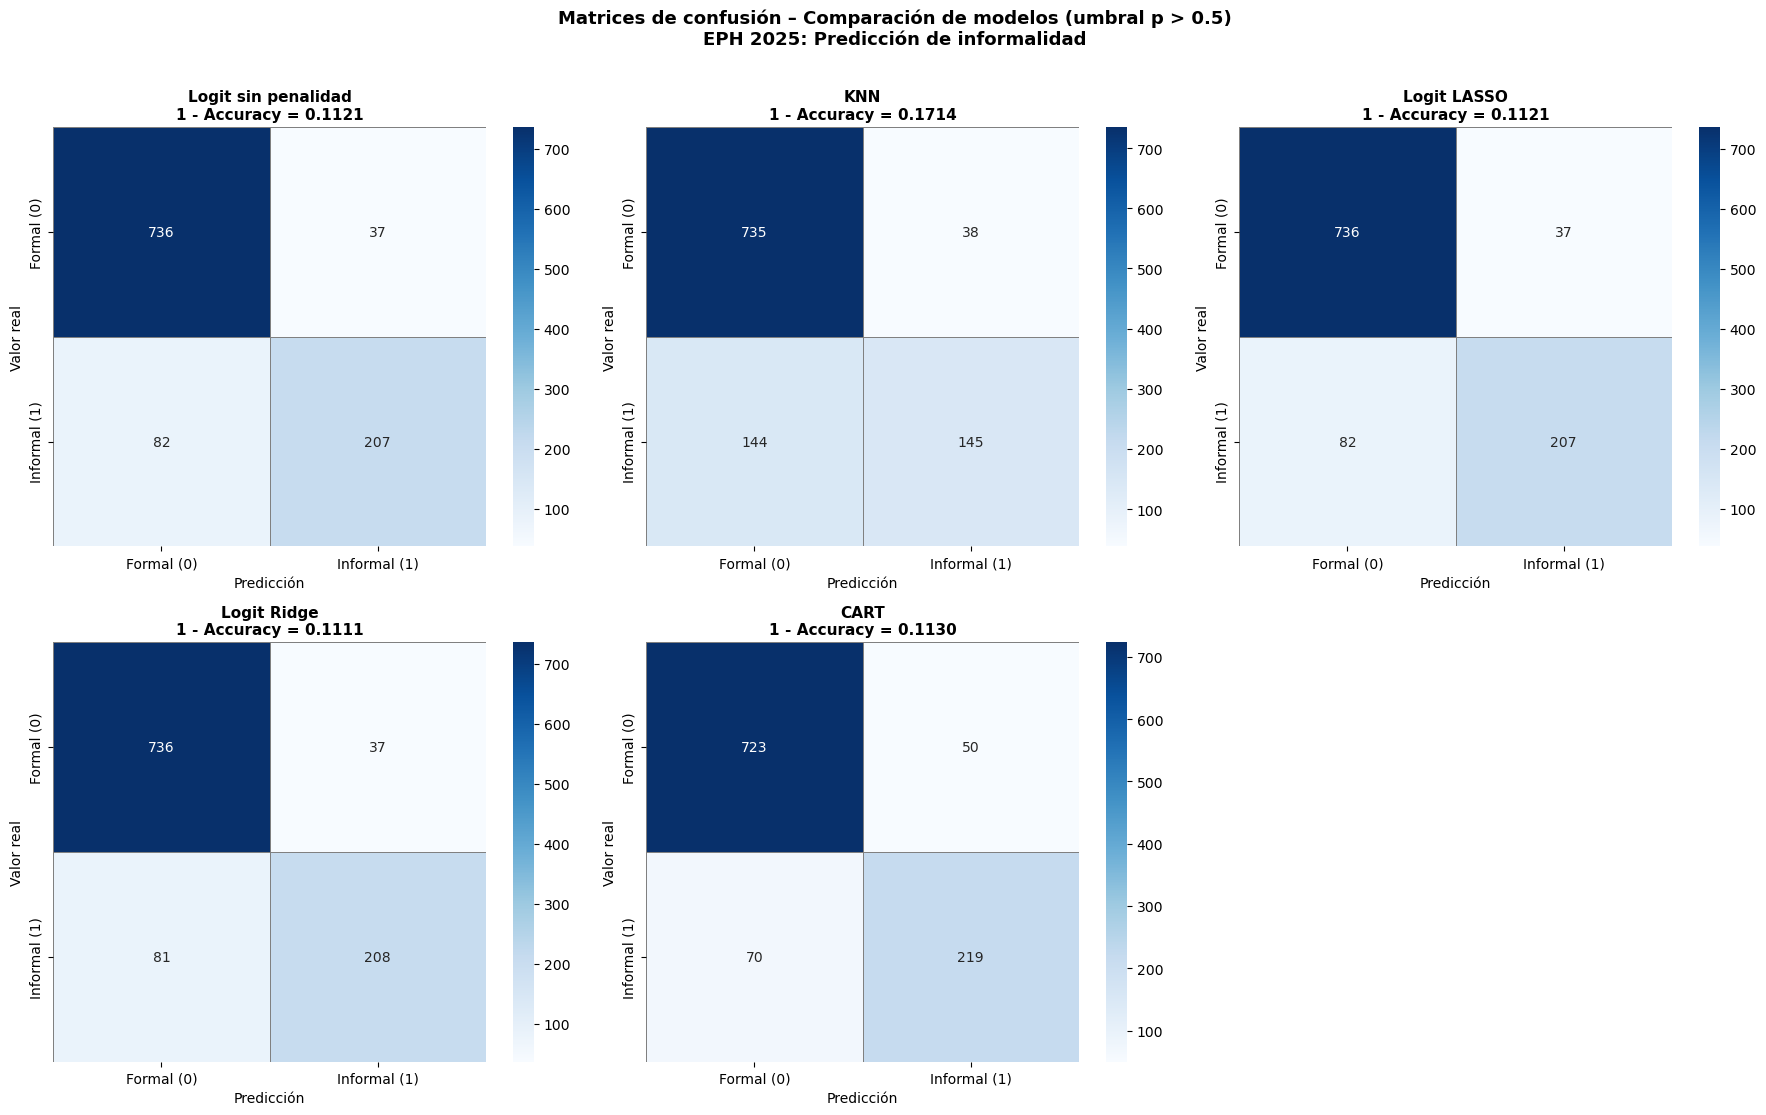

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (nombre, preds) in enumerate(predicciones.items()):
    cm  = confusion_matrix(y_test, preds['y_pred'])
    acc = accuracy_score(y_test, preds['y_pred'])

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Formal (0)', 'Informal (1)'],
                yticklabels=['Formal (0)', 'Informal (1)'],
                linewidths=0.5, linecolor='grey')

    axes[i].set_title(f'{nombre}\n1 - Accuracy = {(1 - acc):.4f}',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicción', fontsize=10)
    axes[i].set_ylabel('Valor real',  fontsize=10)

axes[5].set_visible(False)  

plt.suptitle('Matrices de confusión – Comparación de modelos (umbral p > 0.5)\nEPH 2025: Predicción de informalidad',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('TP5_B3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

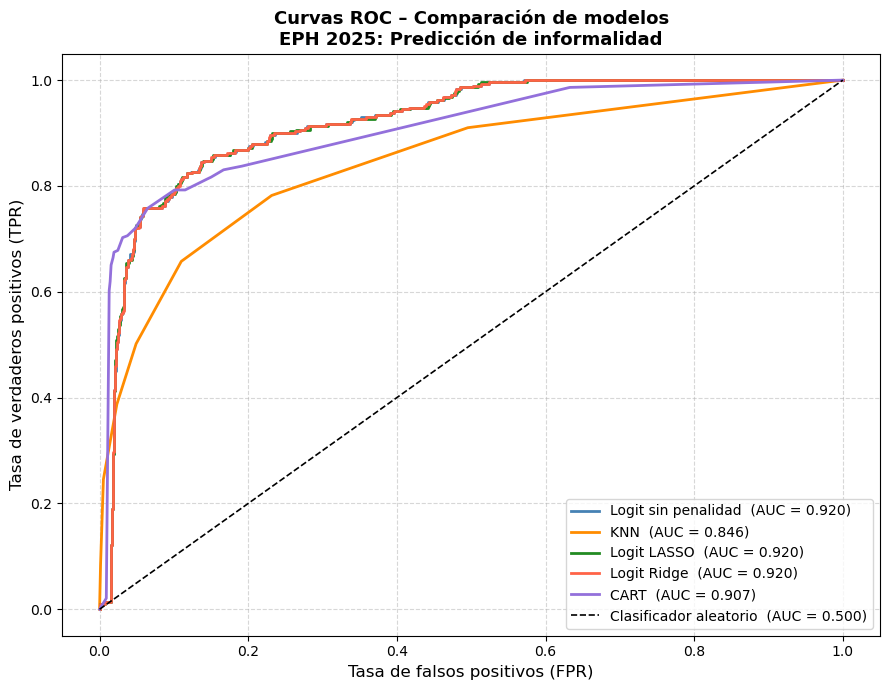

In [11]:
colores = ['steelblue', 'darkorange', 'forestgreen', 'tomato', 'mediumpurple']

plt.figure(figsize=(9, 7))

for (nombre, preds), color in zip(predicciones.items(), colores):
    fpr, tpr, _ = roc_curve(y_test, preds['y_prob'])
    auc          = roc_auc_score(y_test, preds['y_prob'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{nombre}  (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Clasificador aleatorio  (AUC = 0.500)')

plt.xlabel('Tasa de falsos positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de verdaderos positivos (TPR)', fontsize=12)
plt.title('Curvas ROC – Comparación de modelos\nEPH 2025: Predicción de informalidad',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('TP5_B3_curvas_ROC.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
filas = []
for nombre, preds in predicciones.items():
    y_pred = preds['y_pred']
    y_prob = preds['y_prob']

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred)

    filas.append({
        'Modelo'        : nombre,
        'Error (1-Acc)' : round(1 - acc,               4),
        'AUC'           : round(roc_auc_score(y_test, y_prob), 4),
        'Sensibilidad'  : round(tp / (tp + fn),        4),
        'Especificidad' : round(tn / (tn + fp),        4),
    })

tabla = pd.DataFrame(filas).set_index('Modelo')
print(tabla.to_string())

                     Error (1-Acc)     AUC  Sensibilidad  Especificidad
Modelo                                                                 
Logit sin penalidad         0.1121  0.9197        0.7163         0.9521
KNN                         0.1714  0.8458        0.5017         0.9508
Logit LASSO                 0.1121  0.9198        0.7163         0.9521
Logit Ridge                 0.1111  0.9198        0.7197         0.9521
CART                        0.1130  0.9067        0.7578         0.9353


### Ejercicio 4

In [13]:
filas = []
for nombre, preds in predicciones.items():
    y_pred = preds['y_pred']
    y_prob = preds['y_prob']

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    acc = accuracy_score(y_test, y_pred)

    filas.append({
        'Modelo'        : nombre,
        'Error (1-Acc)' : round(1 - acc,                                4),
        'AUC-ROC'       : round(roc_auc_score(y_test, y_prob),          4),
        'Sensibilidad'  : round(tp / (tp + fn),                         4),
        'Precisión'     : round(precision_score(y_test, y_pred),        4),
        'F1-Score'      : round(f1_score(y_test, y_pred),               4),
        'AP (curva P-R)': round(average_precision_score(y_test, y_prob),4),
    })

tabla = pd.DataFrame(filas).set_index('Modelo')

# Ordenamos por Sensibilidad para destacar la métrica clave
print(tabla.sort_values('Sensibilidad', ascending=False).to_string())

                     Error (1-Acc)  AUC-ROC  Sensibilidad  Precisión  F1-Score  AP (curva P-R)
Modelo                                                                                        
CART                        0.1130   0.9067        0.7578     0.8141    0.7849          0.8120
Logit Ridge                 0.1111   0.9198        0.7197     0.8490    0.7790          0.7644
Logit sin penalidad         0.1121   0.9197        0.7163     0.8484    0.7767          0.7642
Logit LASSO                 0.1121   0.9198        0.7163     0.8484    0.7767          0.7647
KNN                         0.1714   0.8458        0.5017     0.7923    0.6144          0.7001


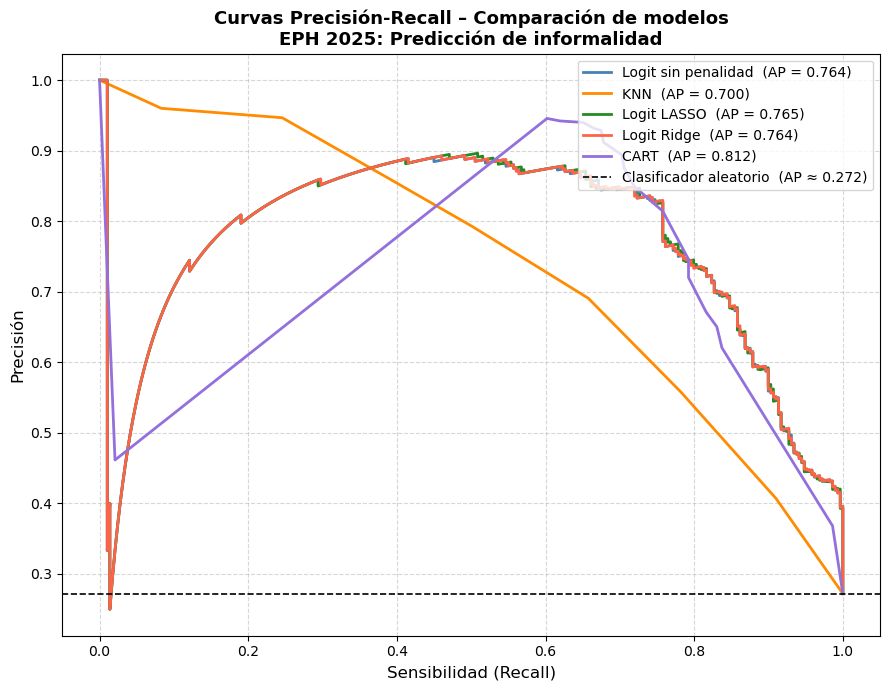

In [14]:
colores = ['steelblue', 'darkorange', 'forestgreen', 'tomato', 'mediumpurple']

plt.figure(figsize=(9, 7))

for (nombre, preds), color in zip(predicciones.items(), colores):
    prec, rec, _ = precision_recall_curve(y_test, preds['y_prob'])
    ap = average_precision_score(y_test, preds['y_prob'])
    plt.plot(rec, prec, color=color, linewidth=2,
             label=f'{nombre}  (AP = {ap:.3f})')

# Línea base: un clasificador que predice siempre "informal" tiene precisión = proporción de informales
baseline = y_test.mean()
plt.axhline(y=baseline, color='k', linestyle='--', linewidth=1.2,
            label=f'Clasificador aleatorio  (AP ≈ {baseline:.3f})')

plt.xlabel('Sensibilidad (Recall)',  fontsize=12)
plt.ylabel('Precisión',              fontsize=12)
plt.title('Curvas Precisión-Recall – Comparación de modelos\nEPH 2025: Predicción de informalidad',
          fontsize=13, fontweight='bold')
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('TP5_B4_curvas_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
y_prob_ridge = predicciones['Logit Ridge']['y_prob']
umbrales = [0.2, 0.3, 0.4, 0.5]

filas_thr = []
for thr in umbrales:
    y_pred_thr = (y_prob_ridge >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    filas_thr.append({
        'Umbral'      : thr,
        'Sensibilidad': round(tp / (tp + fn), 4),
        'Precisión'   : round(tp / (tp + fp), 4),
        'Error'       : round(1 - accuracy_score(y_test, y_pred_thr), 4),
        'FP (formales mal clasificados)': int(fp),
        'FN (informales no detectados)' : int(fn),
    })

tabla_thr = pd.DataFrame(filas_thr).set_index('Umbral')
print('Logit Ridge – impacto del umbral de clasificación:')
print(tabla_thr.to_string())

Logit Ridge – impacto del umbral de clasificación:
        Sensibilidad  Precisión   Error  FP (formales mal clasificados)  FN (informales no detectados)
Umbral                                                                                                
0.2           0.8789     0.6091  0.1864                             163                             35
0.3           0.8408     0.6963  0.1431                             106                             46
0.4           0.7751     0.7568  0.1290                              72                             65
0.5           0.7197     0.8490  0.1111                              37                             81


# C. Herramientas de reflexión e IA

Realizado en el documento de LaTeX. 